<a href="https://colab.research.google.com/github/GermanAlmanza14/Econometria_con_Python/blob/main/wage1_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### License: Creative Commons Attribution 4.0 International (CC BY 4.0)
This work is licensed under a [Creative Commons Attribution 4.0 International License](https://creativecommons.org/licenses/by/4.0/).
<br>
© 2025 Germán Almanza ralmanza@uacj.mx


# **Ejemplo 3.2 WAGE1: ecuación de salario por hora**

Volvemos a la base de datos **wage1**, que consiste de una muestra de 526 observaciones de la población trabajadora en el año 1976. Para explicar el salario de los individuos vamos a considerar la siguiente ecuación
## $$\widehat{\log(wage)}=\beta_0+\beta_1 educ+\beta_2 exper+\beta_3 tenure.$$


<br>

### **Variables:**

* *wage:* promedio del salario por hora,
* *educ:* años de educación,
* *exper:* años de experiencia en el mercado laboral,
* *tenure:* años de antigüedad en el empleo actual.


<br>

---


La descripción de las variables esta en el **github** de
[spring-haru](https://github.com/spring-haru/wooldridge/blob/master/wooldridge/description).


In [ ]:
!pip install wooldridge

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 22.8 MB/s eta 0:00:00


In [ ]:
import statsmodels.formula.api as stf
import wooldridge as woo
import numpy as np

wage1=woo.dataWoo('wage1')
wage1

,wage,educ,exper,tenure,nonwhite,female,married,numdep,smsa,northcen,...,trcommpu,trade,services,profserv,profocc,clerocc,servocc,lwage,expersq,tenursq
0,3.10,11,2,0,0,1,0,2,1,0,...,0,0,0,0,0,0,0,1.131402,4,0
1,3.24,12,22,2,0,1,1,3,1,0,...,0,0,1,0,0,0,1,1.175573,484,4
2,3.00,11,2,0,0,0,0,2,0,0,...,0,1,0,0,0,0,0,1.098612,4,0
3,6.00,8,44,28,0,0,1,0,1,0,...,0,0,0,0,0,1,0,1.791759,1936,784
4,5.30,12,7,2,0,0,1,1,0,0,...,0,0,0,0,0,0,0,1.667707,49,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
521,15.00,16,14,2,0,1,1,2,0,0,...,0,0,0,1,1,0,0,2.708050,196,4
522,2.27,10,2,0,0,1,0,3,0,0,...,0,1,0,0,1,0,0,0.819780,4,0
523,4.67,15,13,18,0,0,1,3,0,0,...,0,0,0,0,1,0,0,1.541159,169,324
524,11.56,16,5,1,0,0,1,0,0,0,...,0,0,0,0,0,0,0,2.447551,25,1


In [ ]:
# Estimación multilineal
regwage1 =stf.ols('np.log(wage)~educ+exper+tenure', data=wage1).fit()
regwage1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           np.log(wage)   R-squared:                       0.316
Model:                            OLS   Adj. R-squared:                  0.312
Method:                 Least Squares   F-statistic:                     80.39
Date:                Wed, 12 Nov 2025   Prob (F-statistic):           9.13e-43
Time:                        20:01:49   Log-Likelihood:                -313.55
No. Observations:                 526   AIC:                             635.1
Df Residuals:                     522   BIC:                             652.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.2844      0.104      2.729      0.007       0.080       0.489
educ           0.0920      0.007     12.555      0.000       0.078       0.106
exper          0.0041      0.002      2.391      0.017       0.001       0.008
tenure         0.0221      0.003      7.133      0.000       0.016       0.028
==============================================================================
Omnibus:                       11.534   Durbin-Watson:                   1.769
Prob(Omnibus):                  0.003   Jarque-Bera (JB):               20.941
Skew:                           0.021   Prob(JB):                     2.84e-05
Kurtosis:                       3.977   Cond. No.                         135.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

##**Interpretación:**


Debido a que la variable a explicar es $\log(wage)$, los estimadores tienen una interpretación porcentual dada por la fórmula
$$100\times\Big(\frac{\Delta y}{y}\Big)=100\times\big(\exp(\beta_i\cdot\Delta x_i)-1\big).$$

* El estimador $\beta_1=0.0920$ asumiendo constantes *exper* y *tenure*, asegura que por  cada año más de *educación*, el salario del empleado incrementa poco más de $100\times(exp(0.0920)-1)=9.6\%$,

* $\beta_2=0.0041$ tiene un impacto muy pequeño, sin embargo, asumiendo constantes *educ* y *tenure*, considerando tres años más de *experiencia* el salario incrementa en $100\times(exp(0.0041\times 3)-1)=1.23\%$.

* Finalmente $\beta_3=0.0221$ asumiendo constantes *educ* y *exper*, un año más de *antiguedad* (*tenure*) tiene un impacto en el salario de $2.2\%=100\times(\exp(0.0221)-1)$.

<br>

---
<br>
La fórmula de interpretación de la regresión log-lin Wooldridge (2010) la presenta en la ecuación [6.8] página 190. En mi notebook desarrollo la explicación matemática.

```Logarithm_02.ipynb```



In [ ]:
# Fórmula

100*(np.exp(0.0221*1)-1)

np.float64(2.234601396027469)

# **1. Análisis estadístico de los regresores**

#**1. Error estandar de los residuales**

Antes de calcular el error estandar (ee) de los residuales comenzaremos por identificar a estos en python.

## *Residuales de la regresión $\widehat{u_i}=y_i-\widehat{y_i}$**

La función `.resid` aplicada a la variable de la regresión nos genera los residuales. Una vez que hemos definido los residuales, vale la pena mostrar mostrar la siguiente **propiedad**:
$$\sum_{i=1}^n\widehat{u_i}=0.$$

con la función `sum()`.


In [ ]:
residuals_wage1=regwage1.resid
residuals_wage1

,0
0,-0.173519
1,-0.347933
2,-0.206308
3,-0.028043
4,0.206017
...,...
521,0.849397
522,-0.393112
523,-0.574420
524,0.648055


In [ ]:
sum(residuals_wage1)

-1.5705214906347464e-12

## **2. Suma de los residuales al cuadrado (ssr)**

Una vez que hemos identificado a los residuales realizamos la suma de sus cuadrados

$$ssr=\sum_{i=1}^n \widehat{u_i}^2.$$
En python obtenemos este resultado con la función `.ssr` aplicada a la variable de la regresión.


###**2.1 Estimador de $\widehat{\sigma}^2$**

El estimador de $\widehat{\sigma}^2$ de los residuales esta definido como
$$S^2=\frac{ssr}{n-(k+1)},\qquad(\clubsuit)$$
donde $n$ es el número de observaciones y $k+1$ el número de parámetros $\beta_i$ de la regresión. Si son $k$-variables explicativas, entonces el total de parámetros $\beta$ de la regresión son $k$ más el intercepto $\beta_0$. Llamamos **grados de libertad** al número  $n-(k+1)$. Los grados de libertad de la regresión los obtenemos con la función `.df_resid` aplicada a la variable de la regresión. La fórmula $(\clubsuit)$ corresponde a la ecuación (3.56) de Wooldridge (2010).

###**2.2 Error estandar de MCO**

Finalmente, el error estandar de MCO es la raíz cuadrada del estimador de $\widehat{\sigma}^2$; es decir, la raíz cuadrada de la ecuación $(\clubsuit)$, expresado por la siguiente identidad

$$ee(\widehat{u_i})=S=\sqrt{\frac{ssr}{n-(k+1)}}.$$

En python la función que almacena el estimador de $\widehat{\sigma}^2$ es `.mse_resid` que denota al **error cuadrático medio de los residuos**
*(Mean Squared Error of residuals)*, posteriormente calculamos la raíz cuadrada de MSE y obtenemos el **error estandar de los residuales (RSE)**


* standard error of the regression (SER), **Teorema 3.3** Wooldridge (2010), pag. 102.


In [ ]:
#    Con python
mse=regwage1.mse_resid
rse=np.sqrt(mse)
print(f'Error cuadrático medio de los residuales:{mse:.4f}')
print(f'Error estandar de los residuales:{rse:.4f}')


Error cuadrático medio de los residuales:0.1944
Error estandar de los residuales:0.4409


In [ ]:
#       RAW
#   Varianza de los residuales
sigma2=regwage1.ssr/regwage1.df_resid
#   Error Estandar de la residuales
sigma=np.sqrt(sigma2)

print(f'Estimador de la varianza de los residuales:{sigma2:.4f}')
print(f'Error estandar de los residuales:{sigma:.4f}')


Estimador de la varianza de los residuales:0.1944
Error estandar de los residuales:0.4409


# **3. Error estandar de los estimadores de MCO**


El error estandar de los estimadores $\widehat{\beta_j}$ de MCO esta definido por la fórmula
$$ee(\widehat{\beta_j})
=\frac{S}{\sqrt{tss(\widehat{\beta_j})}}
=\frac{S}{\sqrt{\sum_{i=1}^n(x_{ij}-\overline{x}_{ij})^2}}.$$

En python el error estandar de los estimadores de MCO se obtiene con la función `.bse` aplicada a la variable de la regresión lineal.


Además, si observamos $tss$ es la varianza de los estimadores y esa la obtenemos de la **matriz de varianza covarianza** con la función `.cov_params()`

In [ ]:
#   Variables regresoras
educ=wage1['educ']
exper=wage1['exper']
tenure=wage1['tenure']

#   ee. Variables regresoras
educ_mean=np.mean(educ)
educ_tss = np.sum((educ-educ_mean)**2)
educ_ee=sigma/(educ_tss)**(1/2)
print(f'Error estandar de educ:{educ_ee:.3f}')
#----
exper_mean=np.mean(exper)
exper_tss = np.sum((exper-exper_mean)**2)
exper_ee=sigma/(exper_tss)**(1/2)
print(f'Error estandar de exper:{exper_ee:.3f}')

#----
tenure_mean=np.mean(tenure)
tenure_tss = np.sum((tenure-tenure_mean)**2)
tenure_ee=sigma/(tenure_tss)**(1/2)
print(f'Error estandar de tenure:{tenure_ee:.3f}')



Error estandar de educ:0.007
Error estandar de exper:0.001
Error estandar de tenure:0.003


In [ ]:
#residuals=regwage1.resid
standard_errors=regwage1.bse
round(standard_errors,12)

,0
Intercept,0.104190
educ,0.007330
exper,0.001723
tenure,0.003094


In [ ]:
Matrix_VarCov=regwage1.cov_params()
Matrix_VarCov

,Intercept,educ,exper,tenure
Intercept,0.010856,-0.000729,-0.000087,0.000029
educ,-0.000729,0.000054,0.000004,-0.000003
exper,-0.000087,0.000004,0.000003,-0.000003
tenure,0.000029,-0.000003,-0.000003,0.000010


In [ ]:
round(np.sqrt(Matrix_VarCov),4)

/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in sqrt
  result = func(self.values, **kwargs)


,Intercept,educ,exper,tenure
Intercept,0.1042,NaN,NaN,0.0054
educ,NaN,0.0073,0.0020,NaN
exper,NaN,0.0020,0.0017,NaN
tenure,0.0054,NaN,NaN,0.0031


In [ ]:
import pandas as pd

table_wage1 = pd.DataFrame({'b': round(regwage1.params, 4),
                            'se': round(regwage1.bse, 4),
                            't': round(regwage1.tvalues, 4),
                            'pval': round(regwage1.pvalues, 4)})
print(f'table_wage1: \n{table_wage1}\n')

table_wage1: 
                b      se        t    pval
Intercept  0.2844  0.1042   2.7292  0.0066
educ       0.0920  0.0073  12.5552  0.0000
exper      0.0041  0.0017   2.3914  0.0171
tenure     0.0221  0.0031   7.1331  0.0000



#**4. Estadístico-$t_{\beta_j}$**


El estadístico-$t_{\beta_j}$ esta definido como
$$t_{\beta_j}=\frac{\widehat{\beta_j}}{ee(\widehat{\beta_j})}.\qquad(\spadesuit)$$
Hasta el momento hemos mostrado varias maneras de calcular $ee(\widehat{\beta_j})$ y para obtener el mismo valor que aparece en el `.summary()` de python es recomendable utilizar el valor de los estadísticos que calcula python. Esto, básicamente para tener claro de donde salen estos resultados. Las siguientes funciones las aplicamos a las variables de la regresión:

* *.params['j']*: estimador $\widehat{\beta_j}$,

* *.bse['j']* error estandar $ee(\widehat{\beta_j})$,

donde $['j']$ es el nombre del estimador.



In [ ]:
educ_b=regwage1.params['educ']
educ_ee=regwage1.bse['educ']
educ_t=educ_b/educ_ee

exper_b=regwage1.params['exper']
exper_ee=regwage1.bse['exper']
exper_t=exper_b/exper_ee

tenure_b=regwage1.params['tenure']
tenure_ee=regwage1.bse['tenure']
tenure_t=tenure_b/tenure_ee

print(f'Estadísito-t de educ: {educ_t:.4f}')
print(f'Estadísito-t de exper: {exper_t:.4f}')
print(f'Estadísito-t de tenure: {tenure_t:.4f}')


Estadísito-t de educ: 12.5552
Estadísito-t de exper: 2.3914
Estadísito-t de tenure: 7.1331


#**5. Prueba de hipótesis $H_0:\;\beta_j=0$**

Asumiendo la regresión
$$y=\beta_0+\beta_1 x_1+\beta_2 x_2+\dots+\beta_k x_k+u.$$
La hipótesis nula $H_0: \beta_j=0$ significa que  una vez que las demás variables $x_i\neq x_j$ han sido tomadas en cuenta, el "impacto" de la variable $x_j$  **no tiene efecto** sobre la variable $y$. En caso de rechazar $H_0$ tenemos las siguientes hipótesis alternas

* $H_1: \beta_j>0$, en tal caso la variable $x_j$ tiene un impacto positivo en $y$,

* $H_1: \beta_j< 0$, esto significa que variable $x_j$ tiene un impacto negativo en $y$,

La hipótesis nula plantea
$$H_0: \beta_j=0,$$
recordemos que $\beta_j$ no es observable, por lo tanto, nuestro objeto de análisis es el estimador insesgado $\widehat{\beta_j}$.
 En cualquier aplicación interesante, el estimador  $\widehat{\beta_j}$ nunca es exactamente cero, sea o no verdadera $H_0$. De modo que, planteamos medir

 <center>¿qué tan lejos está $\widehat{\beta_j}$ de cero?
 </center>

El error estándar de $\widehat{\beta_j}$ es una estimación de la desviación estándar de $\widehat{\beta_j}$, por otra pate, recordemos que $t_{\beta_j}$ mide a cuántas desviaciones estándar se encuentra $\widehat{\beta_j}$ de cero.


Si el valor de $t_{\widehat{\beta_j}}$ se encuentra suficientemente lejos de cero se rechazará $H_0$. El término "suficientemente" depende de la **hipótesis alternativa** $H_i$ y del **nivel de significancia** $\alpha$ elegido para la prueba.


* **Observa que:** estamos probando hipótesis acerca de **parámetros poblacionales** $\pmb{\beta_j}$ y no  acerca de estimaciones $\widehat{\beta_j}$; es decir,  si el valor poblacional desconocido $\beta_j$ es cero.
<br>

###**5.1 Regla de rechazo para $H_0$**

Considerando un **nivel de significancia $\alpha\%$**, este corresponde al **percentil** $1-\alpha$ de una **distribución-$t$ con $\pmb{n-(k+1)}$ gl** (grados de libertad) que denotamos $c_\alpha$. En otras palabras, rechazamos $H_0$ con nivel de significancia $\alpha\%$ si el estadístico $t_{\widehat{\beta_j}}$ es mayor que el **valor crítico** $c_\alpha$ para $\alpha$; en otros términos

$$\text{Si }\quad t_{\widehat{\beta_j}}>c_\alpha
\quad\Longrightarrow\quad
H_0:\;\beta_j=0\;\text{se rechaza}.$$

El valor crítico $c_\alpha$ se calcula de la [tablas de distribución](https://alumnosuacj-my.sharepoint.com/:b:/g/personal/ralmanza_uacj_mx/EfvZfgTK-qZNiNLB82lkZLkBkLTlMTkOf2T1u9BqBl209w?e=hq4nIs) t-Student, considerando un nivel de significancia $(1-\alpha)$ y $gl$-grados de libertad.


<br>

###**Ejemplo [tablas]:** Asumiendo un nivel de significancia de $\alpha=0.95$ y $20$-gl, para una prueda de una cola, se tiene el valor crítico $c_\alpha=1.725$.

**Observación:** Recuerda que la curva de la distribución t-Student es simétrica, por lo tanto, las tablas presentan los niveles de significancia tipicos y hay que considerar la simetría de la curva. Si nos interesa $\alpha=0.05$ y $20$-gl, el valor crítico estará del lado derecho de la curva; es decir, $c_\alpha=-1.725$


<br>

###**Ejemplo [python]:** En python el paquete `scipy.stats` incluye la función `st.t.ppf`($\alpha$,gl), donde $\alpha$ es el nivel de significancia y $gl$ son los grados de libertad.



```
import scipy.stats as st

st.t.ppf(.95,20)

st.t.ppf(.05,20)

```




In [ ]:
import scipy.stats as st

st.t.ppf(.05,20)

np.float64(-1.7247182429207863)

In [ ]:
regwage1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           np.log(wage)   R-squared:                       0.316
Model:                            OLS   Adj. R-squared:                  0.312
Method:                 Least Squares   F-statistic:                     80.39
Date:                Wed, 12 Nov 2025   Prob (F-statistic):           9.13e-43
Time:                        20:01:50   Log-Likelihood:                -313.55
No. Observations:                 526   AIC:                             635.1
Df Residuals:                     522   BIC:                             652.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.2844      0.104      2.729      0.007       0.080       0.489
educ           0.0920      0.007     12.555      0.000       0.078       0.106
exper          0.0041      0.002      2.391      0.017       0.001       0.008
tenure         0.0221      0.003      7.133      0.000       0.016       0.028
==============================================================================
Omnibus:                       11.534   Durbin-Watson:                   1.769
Prob(Omnibus):                  0.003   Jarque-Bera (JB):               20.941
Skew:                           0.021   Prob(JB):                     2.84e-05
Kurtosis:                       3.977   Cond. No.                         135.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### **Evaluamos el estimador 'educ'**
con niv.sig. .95 y gl=522


In [ ]:
cr_t=st.t.ppf(.99,522)
t_educ=12.555
print(f'valor critico={cr_t:.4f}')
print(f't-value de educ={t_educ:.4f}')


valor critico=2.3335
t-value de educ=12.5550


# **5.1.2 Guardar gráficas `plt.savefig()`**

En las pruebas de hipótesis intervienen las curvas de distribución y en ocaciones resulta interesante incluirlas en los reportes. Para esto vamos a incluir una recomendación de como guardar estas gráficas con una mejor "calidad". Cuando incluimos "muchas" gráficas, es importante tener una carpeta (en Drive) donde guardar estos archivos. Para esto, montamos nuestro drive


```python
from google.colab import drive

drive.mount('/content/drive')
```
y definimos la ruta de la carpeta donde vamos guardar los archivos

```python
path='/content/drive/MyDrive/Colab Notebooks/0Figure/'
```

In [ ]:
#       1.
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path='/content/drive/MyDrive/Colab Notebooks/0Figure/'

##**Prueba de una cola**

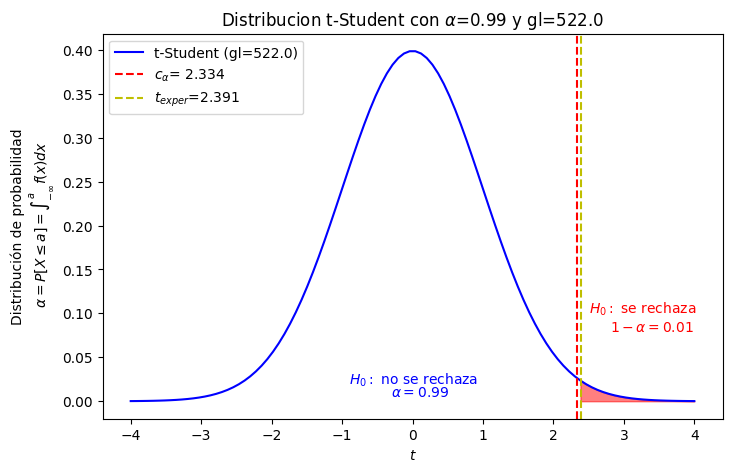

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st


#   nivel de significancia
alpha=.99

#   Grados de libertad
#   Ya lo hemos definido con   '.df_resid'
gl=regwage1.df_resid

########       t-critico (1-cola)       ############
#      t-critico correspondiente a los gl de OLS
t_cr=st.t.ppf(alpha, gl)


#     t-value//estadistico-t_{\beta_j} del estimador $\beta_j$
#     Estos son los t-values que presenta .summary()
tBj=exper_t
t_tenure=tenure_t

#               Inicia la gráfica
x=np.linspace(-4, 4, 100)
tcurve=st.t.pdf(x, gl)

plt.figure(figsize=(8, 5))
plt.plot(x,tcurve, label=f't-Student (gl={gl})', color='blue')

# Shade the critical regions
plt.fill_between(x,tcurve, where=x>t_cr, color='red', alpha=0.5)

# Vertical lines for critical values
plt.axvline(t_cr, linestyle='dashed', color='r', label=rf'$c_\alpha$= {t_cr:.3f}')
#  estadistico-t-exper
plt.axvline(tBj, linestyle='dashed', color='y', label=r'$t_{exper}$=' f'{tBj:.3f}')
#  estadistico-t-tenure
#plt.axvline(t_tenure, linestyle='dashed', color='y', label=r'$t_{tenure}$=' f'{t_tenure:.3f}')


#     texto H0
plt.text(-.9,.02, r'$H_0:$ no se rechaza',c='b',fontsize=10)
plt.text(-.3,.005, r'$\alpha=$' f'{alpha:.2f}',c='b',fontsize=10)
plt.text(2.5,.1, r'$H_0:$ se rechaza',c='r',fontsize=10)
plt.text(2.8,.08, r'$1-\alpha=$' f'{1-alpha:.2f}',c='r',fontsize=10)

plt.xlabel(r'$t$')
plt.ylabel('Distribución de probabilidad\n '
            r'$\alpha=P[X\leq a]=\int_{-\infty}^af(x)dx$')
plt.title(r'Distribucion t-Student con $\alpha$=' f'{alpha:.2f} y gl={gl}')
plt.legend()

plt.savefig(path + 'curvaPDF.jpg', dpi=300, bbox_inches='tight')
#plt.savefig(path + 'curvaPDF2.jpg')


plt.show()


## **Interpretación y niv de sig de los estimadores**

las variables explicativas (educ, exper y tenure) son significativas al $0.99$, hemos utilizado el críterio del t-value (una cola) porque estas variables tienen impacto positivo (una cola) en el salario (*wage*).


* *exper*  Demodo que por cada año más de experiencia el salario del trabajador incrementa 0.4%  aproximadamente

* *tenure* Demodo que por un año más de antiguedad el salario incrementa $2.23\%$ aproximadamente.

In [ ]:
100*(np.exp(0.0221*1)-1)

np.float64(2.234601396027469)

##**Prueba de dos colas**

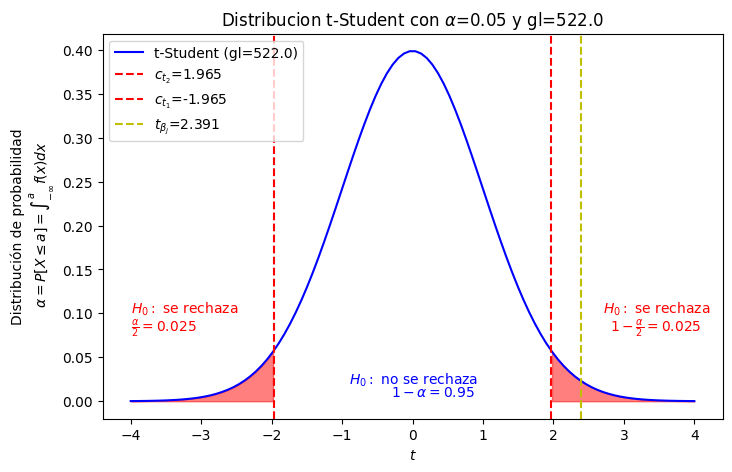

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st


#   nivel de significancia
alpha=.05

#   Grados de libertad
#   Ya lo hemos definido con   '.df_resid'
gl=regwage1.df_resid
########       t-critico (1-cola)       ############
#      t-critico correspondiente a los gl de OLS
t_cr1=st.t.ppf(alpha/2, gl)
t_cr2=st.t.ppf(1-alpha/2, gl)


#     t-value//estadistico-t_{\beta_j} del estimador $\beta_j$
#     Estos son los t-values que presenta .summary()
tBj=exper_t


x=np.linspace(-4, 4, 100)
tcurve=st.t.pdf(x, gl)

plt.figure(figsize=(8, 5))
plt.plot(x,tcurve, label=f't-Student (gl={gl})', color='blue')

# Shade the critical regions
plt.fill_between(x,tcurve, where=x>t_cr2, color='red', alpha=0.5)
plt.fill_between(x,tcurve, where=x<t_cr1, color='red', alpha=0.5)

# Vertical lines for critical values
plt.axvline(t_cr2, linestyle='dashed', color='r', label=r'$c_{t_2}$=' f'{t_cr2:.3f}')
plt.axvline(t_cr1, linestyle='dashed', color='r', label=r'$c_{t_1}$=' f'{t_cr1:.3f}')
#  estadistico-t
plt.axvline(tBj, linestyle='dashed', color='y', label=r'$t_{\beta_j}$=' f'{tBj:.3f}')

#     texto H0
plt.text(-.9,.02, r'$H_0:$ no se rechaza',c='b',fontsize=10)
plt.text(-.3,.005, r'$1-\alpha=$' f'{1-alpha:.2f}',c='b',fontsize=10)
plt.text(-4,.1, r'$H_0:$ se rechaza',c='r',fontsize=10)
plt.text(-4,.08, r'$\frac{\alpha}{2}=$' f'{alpha/2:.3f}',c='r',fontsize=10)
plt.text(2.7,.1, r'$H_0:$ se rechaza',c='r',fontsize=10)
plt.text(2.8,.08, r'$1-\frac{\alpha}{2}=$' f'{alpha/2:.3f}',c='r',fontsize=10)

plt.xlabel(r'$t$')
plt.ylabel('Distribución de probabilidad\n '
            r'$\alpha=P[X\leq a]=\int_{-\infty}^af(x)dx$')
plt.title(r'Distribucion t-Student con $\alpha$=' f'{alpha} y gl={gl}')
plt.legend()

plt.savefig('curvaPDF2t.jpg')
#plt.savefig('curvaPDF2t.jpg', dpi=300, bbox_inches='tight')
#plt.savefig(path + 'curvaPDF2t.jpg', dpi=300, bbox_inches='tight')

plt.show()


#**5.3 El p-value**

El $p-value$ lo obtenemo a partir de la distribución-$t$ asumiendo los $n-(k+1))$  grados de libertad, para determinar la probabilidad de observar un estadístico-$t$ más extremo que el $t_{\widehat{\beta_j}}$ calculado. El $p-value$ que presenta python es para una prueba de dos colas y esta definido como

$$p-value=(2\times P(T>|t_{\widehat{\beta_j}}|)),$$
donde $t_{\widehat{\beta_j}}$ es el estadístico-$t$ de la variable de interés.

Observemos que
$$P(T>|t_{\widehat{\beta_j}}|)$$
denota la probabilidad de encontrar valores $T$ mayores que el $t$-value del estimador $\widehat{\beta_j}$. El valor de esa probabilidad esta definido por la **función de distribución acomulada** (**CDF** por siglas en inglés), en `python` calculamos este valor con la función



```python
import scipy.stats as st

st.t.cdf(a,gl)
```
donde $a$ es el t-value de referencia y $gl$ son los grados de libertad. El resultado corresponde a la probabilidad acumulada desde $-\infty$ hasta el valor de referencia $a$, en otros términos, esto es
$$P[X\leq a]=\int_{-\infty}^af(x)dx.$$



###**5.4 Regla de rechazo de $H_0$ con el p-value**
La hipótesis nula sigue siendo que el coeficiente poblacional $\beta_j$ es cero, esto significa que no hay relación entre la variable independiente y la dependiente. El $p-value$ representa evidencia en contra la hipótesis nula, es necesario asumir un nivel de significancia (niv. sig.) $\alpha$, generalmente se asumen $\alpha=\{0.1,0.05$ y $0.01\}$


$$H_0:\;\beta_j=0,$$

* Se rechaza $H_0$ si $p-val(t_{\widehat{\beta_j}})\;<\;niv. sig. (\alpha)$.

* En caso de que  $p-val(t_{\widehat{\beta_j}})\;>\;niv. sig. (\alpha)$, se concluye que
"no existe suficiente evidencia para rechazar $H_0$".


###**Observación:** Si $p-val(t_{\widehat{\beta_j}})\;>\;niv. sig. (\alpha)$ es **incorrecto** decir "se acepta la hipótesis nula". Decir “aceptamos $H_0$” **sugiere falsamente que hemos probado que $H_0$ es verdadera**, lo cual **no es cierto**, porque:

* La falta de evidencia contra $H_0$ no implica que sea verdadera, solo que no hay evidencia suficiente para rechazarla.

* Siempre existe la posibilidad de un **error tipo II**: no rechazar una hipótesis nula que en realidad es falsa.


In [ ]:
import scipy.stats as st

prob=st.t.cdf(2.391, 522)
p_value=2*(1-prob)

print(f'probabilidad acomulada del t-value={prob:.3f}')
print(f'p-vaue={p_value:.3f}')

probabilidad acomulada del t-value=0.991
p-vaue=0.017


In [ ]:
#   nivel de significancia
alpha=.90
signif=1-alpha

print(f'nivel de significancia (alpha)={signif:.2f}')

if p_value < signif:
    print(f'Dado que p-value={p_value:.4f}< niv. sig.,\n se rechaza H0.')
else:
    print('Dado que p-value={p_value:.4f}> niv. sig.,\n NO se rechaza H0.')


nivel de significancia (alpha)=0.10
Dado que p-value=0.0172< niv. sig.,
 se rechaza H0.


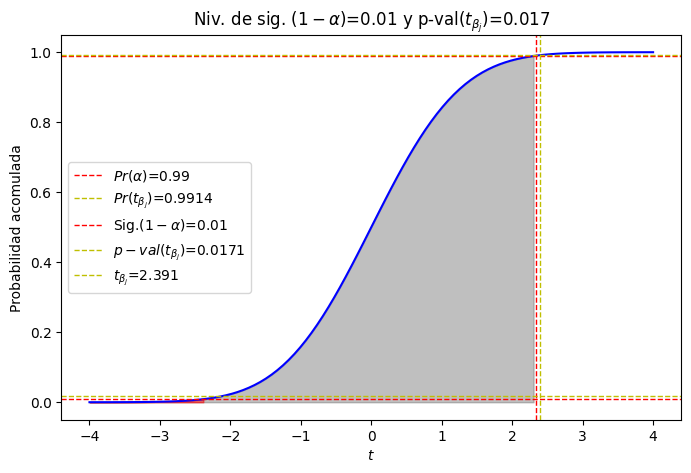

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st


#   nivel de significancia
alpha=.99

#   gl lo hemos definido con   '.df_resid' /or/ agregalo manual
gl=regwage1.df_resid

#      t-critico correspondiente a los gl de OLS
t_cr=st.t.ppf(alpha, gl)

#     t-value//estadistico-t_{\beta_j} del estimador $\beta_j$
#     Estos son los t-values que presenta .summary()
tBj=exper_t
p_tBj=st.t.cdf(tBj,gl)
p_vBj=2*(1-p_tBj)

#               Inicia la gráfica
x=np.linspace(-4, 4, 100)
tcurve=st.t.pdf(x, gl)
CDFcurve=st.t.cdf(x, gl)

plt.figure(figsize=(8, 5))
plt.plot(x,CDFcurve,color='blue')  # label=f't-Student (gl={gl})'

#   Rango de rechazo de H_0
plt.fill_between(x,CDFcurve, where=x<=t_cr,color='gray',alpha=.5)
plt.axvline(t_cr,color='r', linewidth=1,linestyle='dashed')   #  ,label=r'$t_\alpha$='f'{t_cr:.3f}'
plt.axhline(alpha,color='r',linewidth=1,linestyle='dashed',label=r'$Pr(\alpha)$='f'{alpha:.2f}')
plt.axhline(p_tBj,color="y",linewidth=1,linestyle="dashed", label=r'$Pr(t_{\beta_j})$='f'{p_tBj:.4f}')

#plt.ylim(0,0.12)

#    p-value evaluacion
plt.fill_between(x,CDFcurve, where=(CDFcurve<(1-alpha))&(x<t_cr),color='red',alpha=.5)
plt.axhline((1-alpha),color='r',linewidth=1,linestyle='dashed',label=r'Sig.$(1-\alpha)$='f'{(1-alpha):.2f}')
plt.axhline(p_vBj,color="y",linewidth=1,linestyle="dashed", label=r'$p-val(t_{\beta_j})$='f'{p_vBj:.4f}')
plt.axvline(tBj,color="y",linewidth=1,linestyle="dashed", label=r'$t_{\beta_j}$=' f'{tBj:.3f}')

plt.xlabel(r'$t$')
plt.ylabel('Probabilidad acomulada')
plt.title(r'Niv. de sig. $(1-\alpha)$=' f'{1-alpha:.2f}'  r' y p-val($t_{\beta_j}$)='f'{p_vBj:.3f}')
plt.legend()
plt.show()


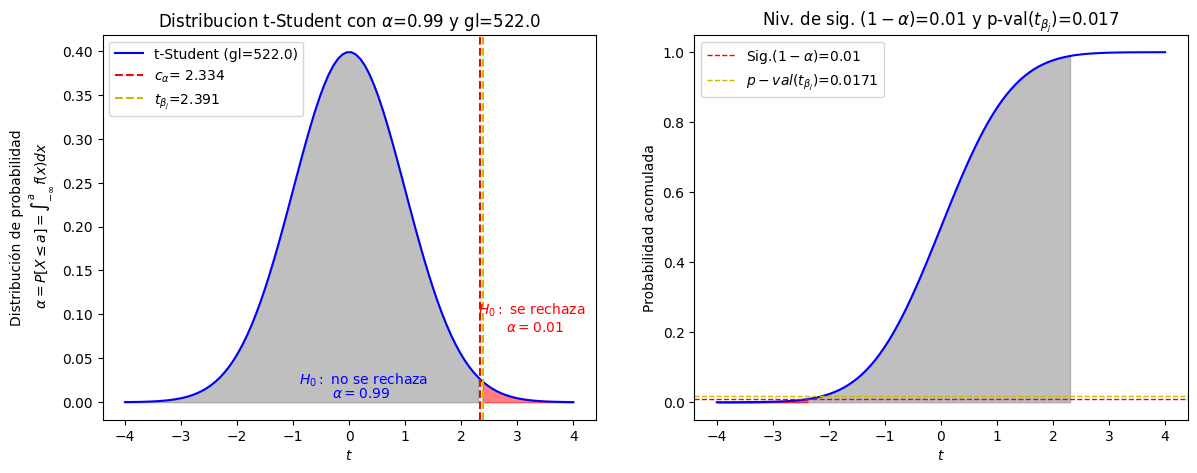

In [ ]:
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt

#   nivel de significancia
alpha=.99

#   gl lo hemos definido con   '.df_resid' /or/ agregalo manual
gl=regwage1.df_resid

#      t-critico correspondiente a los gl de OLS
t_cr=st.t.ppf(alpha, gl)

#     t-value//estadistico-t_{\beta_j} del estimador $\beta_j$
#     Estos son los t-values que presenta .summary()
tBj=exper_t
p_tBj=st.t.cdf(tBj,gl)
p_vBj=2*(1-p_tBj)

#               Inicia la gráfica
x=np.linspace(-4, 4, 100)
tcurve=st.t.pdf(x, gl)
CDFcurve=st.t.cdf(x, gl)

# Graficando las distribuciones #
plt.figure(figsize = (14,5))
#############################################################
#                            (a)
#############################################################
plt.subplot(1,2,1)
#   Gráfica de curva PDF

plt.plot(x,tcurve, label=f't-Student (gl={gl})', color='blue')

# Shade the critical regions
plt.fill_between(x,tcurve, where=x>t_cr, color='r', alpha=0.5)
plt.fill_between(x,tcurve, where=x<t_cr, color='gray', alpha=0.5)

# Vertical lines for critical values
plt.axvline(t_cr, linestyle='dashed', color='r', label=rf'$c_\alpha$= {t_cr:.3f}')
#  estadistico-t
plt.axvline(tBj, linestyle='dashed', color='y', label=r'$t_{\beta_j}$=' f'{tBj:.3f}')

#     texto H0
plt.text(-.9,.02, r'$H_0:$ no se rechaza',c='b',fontsize=10)
plt.text(-.3,.005, r'$\alpha=$' f'{alpha:.2f}',c='b',fontsize=10)
plt.text(2.3,.1, r'$H_0:$ se rechaza',c='r',fontsize=10)
plt.text(2.8,.08, r'$\alpha=$' f'{1-alpha:.2f}',c='r',fontsize=10)

plt.xlabel(r'$t$')
plt.ylabel('Distribución de probabilidad\n '
            r'$\alpha=P[X\leq a]=\int_{-\infty}^af(x)dx$')
plt.title(r'Distribucion t-Student con $\alpha$=' f'{alpha} y gl={gl}')
plt.legend()

plt.savefig('curvaPDF.jpg', dpi=300, bbox_inches='tight')

#############################################################
#                            (b)
#############################################################
plt.subplot(1,2,2)
#   Gráfica de la curva CDF
plt.plot(x,CDFcurve,color='blue')  # label=f't-Student (gl={gl})'

#   Rango de rechazo de H_0
plt.fill_between(x,CDFcurve, where=x<=t_cr,color='gray',alpha=.5)
#plt.axvline(t_cr,color='r', linewidth=1,linestyle='dashed')   #  ,label=r'$t_\alpha$='f'{t_cr:.3f}'
#plt.axhline(alpha,color='r',linewidth=1,linestyle='dashed',label=r'$Pr(\alpha)$='f'{alpha:.2f}')
#plt.axhline(p_tBj,color="y",linewidth=1,linestyle="dashed", label=r'$Pr(t_{\beta_j})$='f'{p_tBj:.4f}')


#    p-value evaluacion
plt.fill_between(x,CDFcurve, where=(CDFcurve<(1-alpha))&(x<t_cr),color='red',alpha=.5)
plt.axhline((1-alpha),color='r',linewidth=1,linestyle='dashed',label=r'Sig.$(1-\alpha)$='f'{(1-alpha):.2f}')
plt.axhline(p_vBj,color="y",linewidth=1,linestyle="dashed", label=r'$p-val(t_{\beta_j})$='f'{p_vBj:.4f}')
#plt.axvline(tBj,color="y",linewidth=1,linestyle="dashed", label=r'$t_{\beta_j}$=' f'{tBj:.3f}')

plt.xlabel(r'$t$')
plt.ylabel('Probabilidad acomulada')
plt.title(r'Niv. de sig. $(1-\alpha)$=' f'{1-alpha:.2f}'  r' y p-val($t_{\beta_j}$)='f'{p_vBj:.3f}')
plt.legend()

plt.savefig(path+'curvaPDF-CDF.jpg', dpi=300, bbox_inches='tight')


plt.show()